# Sound-Based Spin Estimation in Table Tennis
## Part 2: Bounce Sound Classification

This notebook trains and evaluates the **CNN classifier** for:
1. **Surface classification** (13 classes: 10 rackets + table + floor + other)
2. **Spin classification** (3 classes: backspin, no-spin, topspin)

We also compare against an **SVM baseline**.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as lightning
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

from dataset import SoundDS, SURFACE_CLASSES, SPIN_CLASSES,SoundDataModule
from classifier.cnn import AudioClassifier
import plots

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.style.use("dark_background")

DATA_DIR = '../data'
MODEL_DIR = '../models'
SOUNDS_DIR = f'{DATA_DIR}/sounds'
lightning.seed_everything(42)

Seed set to 42


42

---
## 1.Data Loading

In [2]:
# Load datasets
train_ds = SoundDS(f'{DATA_DIR}/train.csv', SOUNDS_DIR, augment=True)
test_ds = SoundDS(f'{DATA_DIR}/test.csv', SOUNDS_DIR, augment=False)

# Data loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_ds)}")
print(f"Test samples:     {len(test_ds)}")

# Check a sample
mel, surface, spin = train_ds[0]
print(f"\nMel spectrogram shape: {mel.shape}")
print(f"Surface label: {surface.item()} ({SURFACE_CLASSES[surface.item()]})")
print(f"Spin label:    {spin.item()} ({SPIN_CLASSES[spin.item()]})")

Training samples: 4561
Test samples:     1141

Mel spectrogram shape: torch.Size([1, 64, 10])
Surface label: 10 (racket_10)
Spin label:    1 (none)


---
## 2. CNN Training — Surface Classification

In [3]:
# Surface classifier
surface_model = AudioClassifier.load_from_checkpoint(os.path.join(MODEL_DIR, 'surface_best.ckpt'))
print(surface_model)
print(f"\nNumber of parameters: {sum(p.numel() for p in surface_model.parameters()):,}")

AudioClassifier(
  (features): Sequential(
    (0): Conv2d(1, 2, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(2, 4, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 1), pa

Surface Classification Report:
              precision    recall  f1-score   support

       other       0.98      0.99      0.98       248
   racket_01       0.90      0.93      0.91       179
   racket_02       0.87      0.97      0.91        60
   racket_03       0.86      0.78      0.82        55
   racket_04       0.92      0.83      0.87        58
   racket_05       0.93      0.79      0.85        48
   racket_06       0.92      0.88      0.90        41
   racket_07       0.90      0.92      0.91        49
   racket_08       0.97      0.96      0.96        67
   racket_09       0.90      0.88      0.89        59
   racket_10       0.92      0.95      0.94        64
       table       1.00      0.99      1.00       155
       floor       0.94      1.00      0.97        58

    accuracy                           0.94      1141
   macro avg       0.92      0.91      0.92      1141
weighted avg       0.94      0.94      0.94      1141



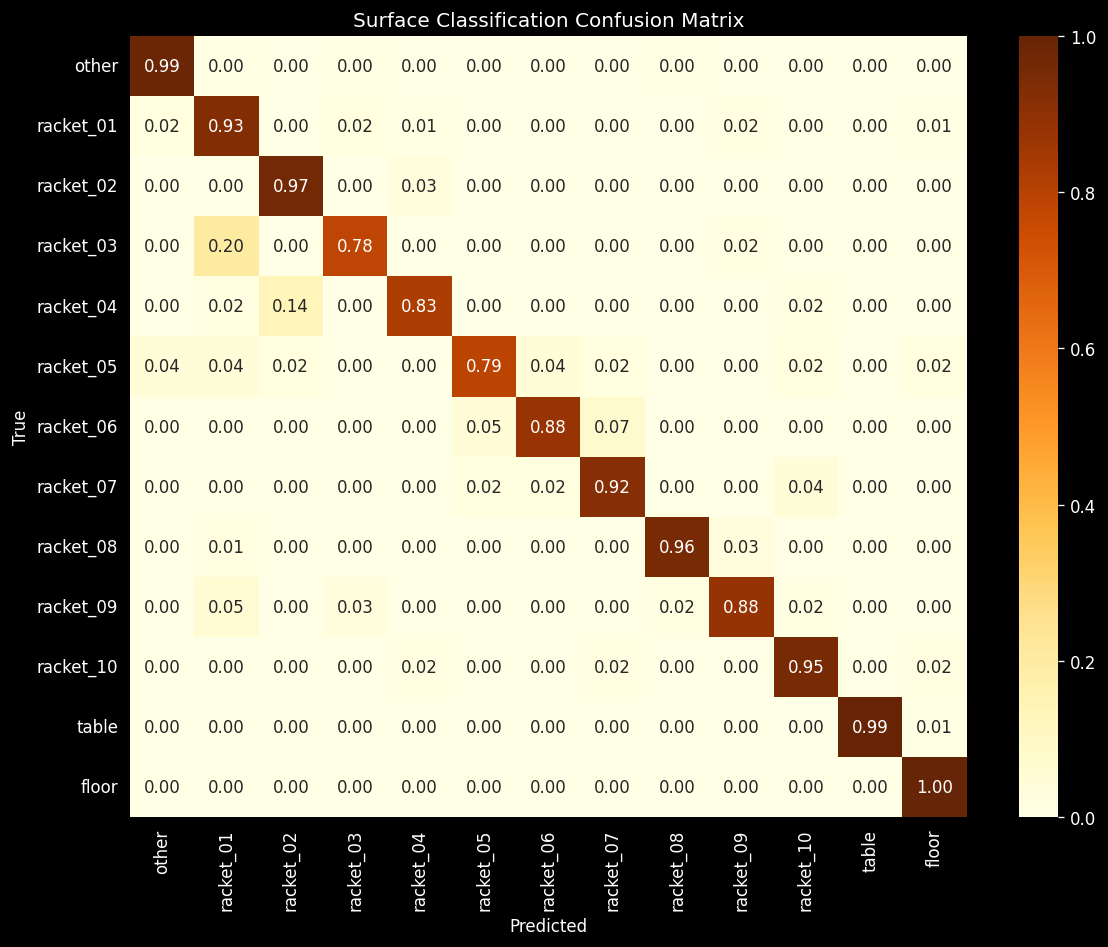

In [8]:
# Evaluate surface classifier
device = next(surface_model.parameters()).device
surface_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for mel, surface, spin in test_loader:
        mel = mel.to(device)
        logits = surface_model(mel)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(surface.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Surface Classification Report:")
# Only show classes that appear in the data
present = sorted(set(all_targets) | set(all_preds))
print(classification_report(all_targets, all_preds,
                           labels=present,
                           target_names=[SURFACE_CLASSES[i] for i in present]))

fig = plots.plot_confusion_matrix(all_targets, all_preds,
                           class_names=[SURFACE_CLASSES[i] for i in present],
                           title='Surface Classification Confusion Matrix')
plt.show()

---
## 3. CNN Training — Spin Classification

In [5]:
# Spin classifier
spin_model = AudioClassifier.load_from_checkpoint(os.path.join(MODEL_DIR, 'spin_best.ckpt'))
print(spin_model)
print(f"\nNumber of parameters: {sum(p.numel() for p in spin_model.parameters()):,}")

AudioClassifier(
  (features): Sequential(
    (0): Conv2d(1, 2, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(2, 4, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 1), pa

Spin Classification Report:
              precision    recall  f1-score   support

        back       0.96      0.90      0.93       230
        none       0.97      0.99      0.98       776
         top       0.89      0.93      0.91       135

    accuracy                           0.96      1141
   macro avg       0.94      0.94      0.94      1141
weighted avg       0.96      0.96      0.96      1141



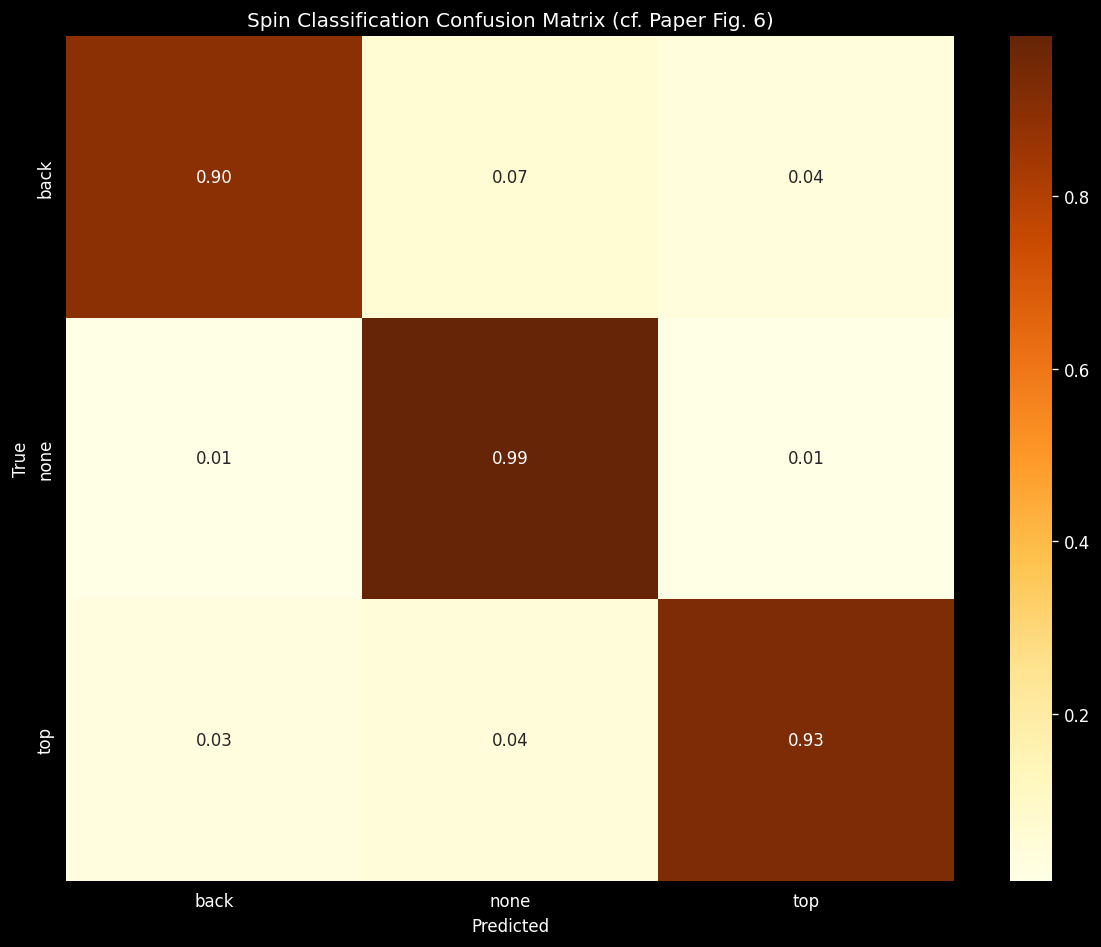

In [6]:
# Evaluate spin classifier
device = next(surface_model.parameters()).device
spin_model.eval()
all_preds_spin = []
all_targets_spin = []

with torch.no_grad():
    for mel, surface, spin in test_loader:
        mel = mel.to(device)
        logits = spin_model(mel)
        preds = logits.argmax(dim=1)
        all_preds_spin.extend(preds.cpu().numpy())
        all_targets_spin.extend(spin.cpu().numpy())

all_preds_spin = np.array(all_preds_spin)
all_targets_spin = np.array(all_targets_spin)

print("Spin Classification Report:")
print(classification_report(all_targets_spin, all_preds_spin,
                           target_names=SPIN_CLASSES))

fig = plots.plot_confusion_matrix(all_targets_spin, all_preds_spin,
                           class_names=SPIN_CLASSES,
                           title='Spin Classification Confusion Matrix (cf. Paper Fig. 6)')
plt.show()